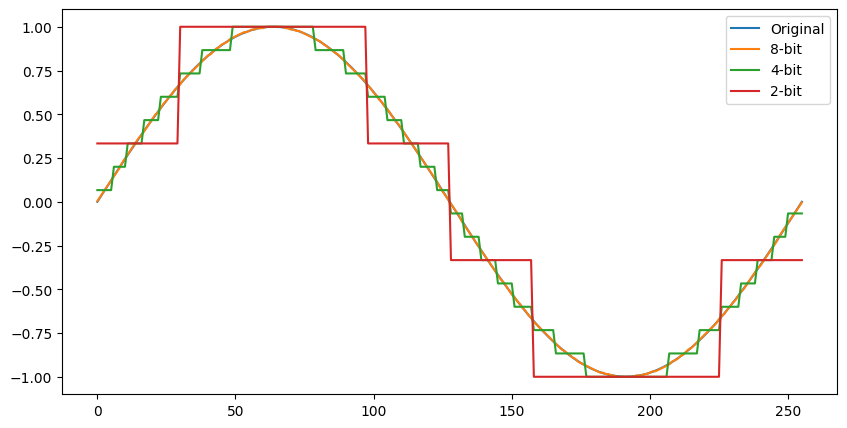

8-bit: 4.851762899815058e-06
4-bit: 0.001366168942310664
2-bit: 0.030289410782984985


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 256

x = np.linspace(0, 2*np.pi, N)
sine = np.sin(x)


def quantize(signal, bits):
    levels = 2**bits
    signal_norm = (signal + 1) / 2
    q = np.round(signal_norm * (levels - 1))
    reconstructed = q / (levels - 1)

    return reconstructed * 2 - 1


def mse(original, quantized):
    return np.mean((original - quantized)**2)


sine_8bit = quantize(sine, 8)
sine_4bit = quantize(sine, 4)
sine_2bit = quantize(sine, 2)

plt.figure(figsize=(10, 5))
plt.plot(sine, label="Original")
plt.plot(sine_8bit, label="8-bit")
plt.plot(sine_4bit, label="4-bit")
plt.plot(sine_2bit, label="2-bit")
plt.legend()
plt.show()


for bits in [8, 4, 2]:
    q = quantize(sine, bits)
    print(f"MSE {bits}-bit:", mse(sine, q))